In [69]:
import numpy as np
import matplotlib.pyplot as plt

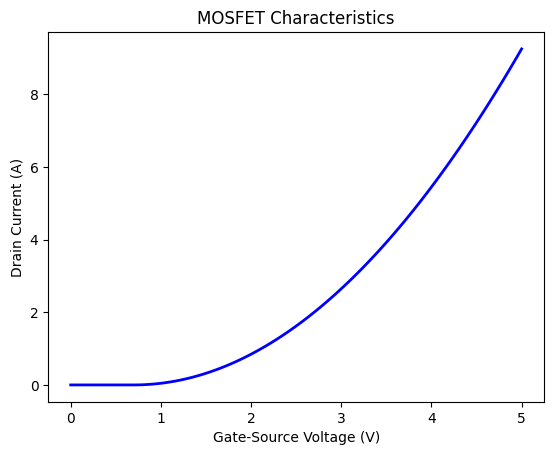

In [70]:
U_T, alpha = 0.7, 1.0
U_GS = np.linspace(0, 5, 100)
I_D = 0.5 * alpha * np.maximum(U_GS - U_T, 0) ** 2

# Plot I_D vs U_GS (Saturation region)
plt.plot(U_GS, I_D, lw=2, color='blue')

# Plot settings
plt.xlabel('Gate-Source Voltage (V)')
plt.ylabel('Drain Current (A)')
plt.title('MOSFET Characteristics')
plt.show()

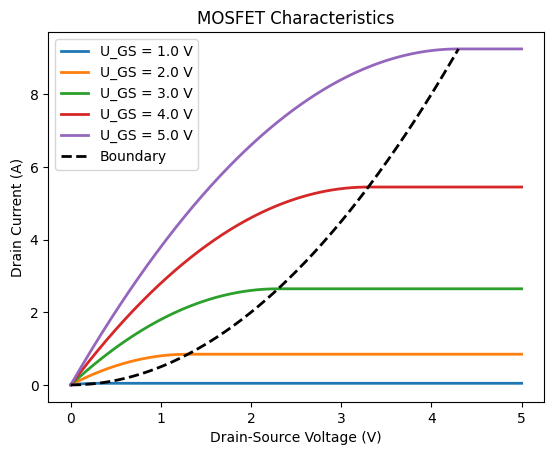

In [71]:
U_DS = np.linspace(0, 5, 400)
U_GS_values = np.array([1, 2, 3, 4, 5])

# Plot I_D vs U_DS for each U_GS value
for U_GS_0 in U_GS_values:
    V_OV = max(U_GS_0 - U_T, 0)
    I_D = np.where(U_DS <= V_OV, alpha * (V_OV - 0.5 * U_DS) * U_DS, 0.5 * alpha * V_OV**2)
    plt.plot(U_DS, I_D, lw=2, label=f'U_GS = {U_GS_0:.1f} V')

# Plot the boundary between triode and saturation regions
u = np.linspace(0, max(U_GS_values - U_T), 300)
plt.plot(u, 0.5 * alpha * u**2, 'k--', lw=2, label='Boundary')

# Plot settings
plt.xlabel('Drain-Source Voltage (V)')
plt.ylabel('Drain Current (A)')
plt.title('MOSFET Characteristics')
plt.legend()
plt.show()

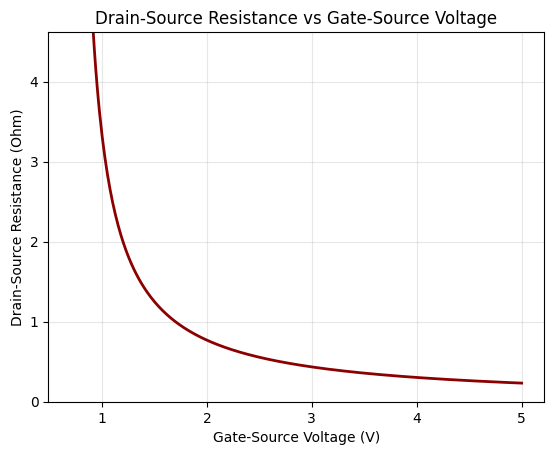

In [72]:
U_GS = np.linspace(0, 5, 400)
R_DS = np.where(U_GS > U_T, 1 / (alpha * (U_GS - U_T)), np.nan)

plt.plot(U_GS, R_DS, lw=2, color='darkred')
plt.xlabel('Gate-Source Voltage (V)')
plt.ylabel('Drain-Source Resistance (Ohm)')
plt.title('Drain-Source Resistance vs Gate-Source Voltage')
plt.ylim(0, np.nanpercentile(R_DS, 95))
plt.grid(True, alpha=0.3)
plt.show()